# Pre-Modeling Steps: Lecture Notebook

This notebook is designed to support the **Pre-Modeling Steps** lecture.

Topics:
- Business problem understanding and feature definition
- Train/validation/test splitting for i.i.d. and time series data
- Data exploration
- Data preprocessing (missing data, imbalance)
- Feature engineering (encoding, scaling)

For each topic you get:
- Core theory summary
- Basic practice
- Intermediate practice
- MCQs

In [1]:
# Core stack requested: numpy, pandas, scipy, scikit-learn
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('Libraries imported successfully.')

Libraries imported successfully.


## Topic 1: Converting Business Problem to Features

### Theory
Convert a business request into an ML problem using this flow:
1. Business goal (what outcome matters)
2. ML task (classification, regression, ranking)
3. Target definition and prediction horizon
4. Observation unit (row meaning)
5. Feature candidates available before prediction time
6. Evaluation metrics tied to business impact

Example:
- Business: reduce churn
- Task: binary classification
- Target: churn_in_30d
- Unit: one row per customer per week

In [2]:
from pprint import pprint

business_to_ml_blueprint = {
    'business_goal': 'Reduce churn by proactive retention campaigns',
    'ml_task': 'binary_classification',
    'target': 'churn_in_30d',
    'observation_unit': 'customer-week snapshot',
    'prediction_horizon': '30 days',
    'candidate_features': [
        'tenure_months',
        'last_login_days',
        'avg_session_minutes_14d',
        'num_support_tickets_30d',
        'plan_type',
        'payment_failures_90d'
    ],
    'model_metrics': ['recall', 'precision', 'pr_auc'],
    'business_metric': 'retained_revenue',
    'guardrail': 'use only features known before prediction date'
}

pprint(business_to_ml_blueprint)

{'business_goal': 'Reduce churn by proactive retention campaigns',
 'business_metric': 'retained_revenue',
 'candidate_features': ['tenure_months',
                        'last_login_days',
                        'avg_session_minutes_14d',
                        'num_support_tickets_30d',
                        'plan_type',
                        'payment_failures_90d'],
 'guardrail': 'use only features known before prediction date',
 'ml_task': 'binary_classification',
 'model_metrics': ['recall', 'precision', 'pr_auc'],
 'observation_unit': 'customer-week snapshot',
 'prediction_horizon': '30 days',
 'target': 'churn_in_30d'}


### Practice
Fill a blueprint for: 'predict late delivery risk for next shipment'.

- Define target
- Define 6 feature candidates
- Define 2 model metrics and 1 business metric

In [3]:
# Student template (Basic)
late_delivery_blueprint = {
    'business_goal': 'TODO',
    'ml_task': 'TODO',
    'target': 'TODO',
    'observation_unit': 'TODO',
    'candidate_features': ['TODO1', 'TODO2', 'TODO3', 'TODO4', 'TODO5', 'TODO6'],
    'model_metrics': ['TODO1', 'TODO2'],
    'business_metric': 'TODO'
}

late_delivery_blueprint

{'business_goal': 'TODO',
 'ml_task': 'TODO',
 'target': 'TODO',
 'observation_unit': 'TODO',
 'candidate_features': ['TODO1', 'TODO2', 'TODO3', 'TODO4', 'TODO5', 'TODO6'],
 'model_metrics': ['TODO1', 'TODO2'],
 'business_metric': 'TODO'}

## Topic 2: Train, Validation, and Test Splitting

### Theory
- i.i.d. data: random split is valid; stratify for classification.
- Time series: split chronologically; no random shuffle.
- Keep test set untouched until final model selection is complete.

In [5]:
# Basic split on i.i.d. classification data
n = 600
X_iid = pd.DataFrame({
    'x1': rng.normal(0, 1, n),
    'x2': rng.normal(3, 2, n),
    'x3': rng.integers(0, 5, n)
})
y_iid = pd.Series(rng.choice([0, 1], size=n, p=[0.85, 0.15]), name='target')

X_train, X_temp, y_train, y_temp = train_test_split(
    X_iid, y_iid, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iid
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print('i.i.d. split sizes ->', len(X_train), len(X_val), len(X_test))
print('Positive ratio train/val/test ->', round(y_train.mean(), 3), round(y_val.mean(), 3), round(y_test.mean(), 3))

i.i.d. split sizes -> 420 90 90
Positive ratio train/val/test -> 0.157 0.156 0.156


In [6]:
# Intermediate split for time series
dates = pd.date_range('2024-01-01', periods=240, freq='D')
ts_df = pd.DataFrame({
    'date': dates,
    'demand': 200 + np.sin(np.arange(240) / 10) * 20 + rng.normal(0, 3, 240),
    'promo': rng.integers(0, 2, 240)
}).sort_values('date').reset_index(drop=True)

train_end = int(len(ts_df) * 0.7)
val_end = int(len(ts_df) * 0.85)
train_ts = ts_df.iloc[:train_end]
val_ts = ts_df.iloc[train_end:val_end]
test_ts = ts_df.iloc[val_end:]

print('Chronological windows:')
print('train:', train_ts['date'].min().date(), '->', train_ts['date'].max().date())
print('val  :', val_ts['date'].min().date(), '->', val_ts['date'].max().date())
print('test :', test_ts['date'].min().date(), '->', test_ts['date'].max().date())

tscv = TimeSeriesSplit(n_splits=4)
print('\nTimeSeriesSplit folds on train+val block:')
for i, (tr_idx, va_idx) in enumerate(tscv.split(ts_df.iloc[:val_end]), start=1):
    print(f'Fold {i}: train[{tr_idx[0]}:{tr_idx[-1]}] val[{va_idx[0]}:{va_idx[-1]}]')

Chronological windows:
train: 2024-01-01 -> 2024-06-16
val  : 2024-06-17 -> 2024-07-22
test : 2024-07-23 -> 2024-08-27

TimeSeriesSplit folds on train+val block:
Fold 1: train[0:43] val[44:83]
Fold 2: train[0:83] val[84:123]
Fold 3: train[0:123] val[124:163]
Fold 4: train[0:163] val[164:203]


### Basic Practice
Create a 60/20/20 random split with stratification and print class ratios for each subset.

In [7]:
# Student template (Basic)
# TODO: implement 60/20/20 split with stratify
pass

### Intermediate Practice
For time series, create a backtesting loop with 3 rolling folds and report MAE for each fold.

In [8]:
# Student template (Intermediate)
# Hints: TimeSeriesSplit + a simple regression model + mean absolute error
pass

### MCQs (Topic 2)
1. Random split is usually valid for:
   A) Time series only
   B) i.i.d. data
   C) Any data with dates
   D) None

2. In time series, test data should be:
   A) Randomly sampled from all years
   B) Earliest chunk
   C) Most recent unseen chunk
   D) A copy of train

3. Stratification is most useful when:
   A) Features are all numeric
   B) Classes are imbalanced
   C) Dataset is tiny
   D) Using PCA

## Topic 3: Data Exploration

### Theory
Exploration should answer modeling questions quickly:
- What is missing?
- What is imbalanced?
- What is noisy or extreme?
- What relationships exist between features and target?

Schema:
age              float64
monthly_spend    float64
tickets_30d        int64
churn              int64
dtype: object

Summary stats:
              age  monthly_spend  tickets_30d      churn
count    9.000000       9.000000     10.00000  10.000000
mean    46.555556      65.555556      1.90000   0.500000
std     29.669476      27.861762      1.66333   0.527046
min     22.000000      30.000000      0.00000   0.000000
25%     29.000000      45.000000      1.00000   0.000000
50%     41.000000      60.000000      1.50000   0.500000
75%     49.000000      85.000000      2.75000   1.000000
max    120.000000     110.000000      5.00000   1.000000

Missing rate (%):
age              10.0
monthly_spend    10.0
tickets_30d       0.0
churn             0.0
dtype: float64

Class balance:
churn
0    0.5
1    0.5
Name: proportion, dtype: float64

Potential age outliers (|z| > 3):
Series([], Name: age, dtype: float64)


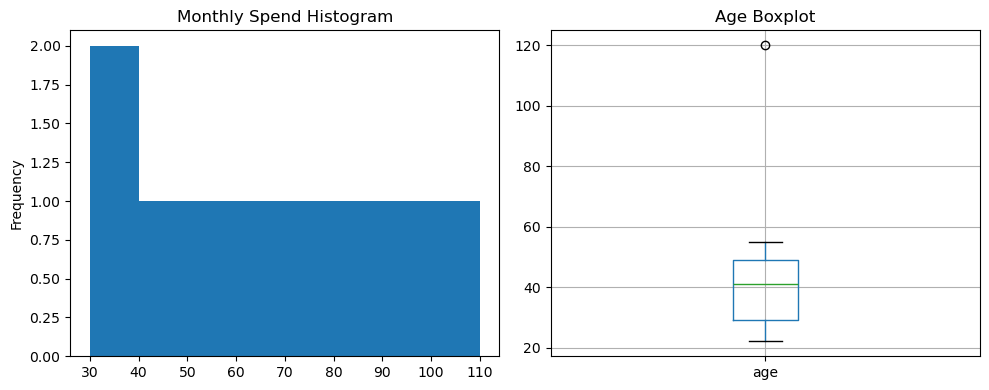

In [9]:
eda_df = pd.DataFrame({
    'age': [22, 25, 29, 34, np.nan, 41, 44, 49, 55, 120],
    'monthly_spend': [30, 35, 45, 52, 60, np.nan, 78, 85, 95, 110],
    'tickets_30d': [0, 1, 0, 2, 3, 1, 5, 2, 4, 1],
    'churn': [0, 0, 0, 1, 0, 1, 1, 0, 1, 1]
})

print('Schema:')
print(eda_df.dtypes)

print('\nSummary stats:')
print(eda_df.describe(include='all'))

print('\nMissing rate (%):')
print((eda_df.isna().mean() * 100).round(1))

print('\nClass balance:')
print(eda_df['churn'].value_counts(normalize=True).round(3))

# Outlier scan with scipy z-score on non-null ages
age_non_null = eda_df['age'].dropna()
z = np.abs(stats.zscore(age_non_null))
print('\nPotential age outliers (|z| > 3):')
print(age_non_null[z > 3])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eda_df['monthly_spend'].plot(kind='hist', bins=8, ax=axes[0], title='Monthly Spend Histogram')
eda_df.boxplot(column='age', ax=axes[1])
axes[1].set_title('Age Boxplot')
plt.tight_layout()
plt.show()

### Basic Practice
Compute missing percentages and identify top 2 columns to clean first.

In [10]:
# Student template (Basic)
# TODO: calculate missing percentage and sort descending
pass

### Intermediate Practice
Build a short EDA report table with columns:
- feature
- dtype
- missing_pct
- n_unique
- recommendation

In [11]:
# Student template (Intermediate)
# TODO: create a DataFrame report for all features
pass

### MCQs (Topic 3)
1. Which is the best first check in EDA?
   A) Hyperparameter tuning
   B) Data schema and missingness
   C) PCA
   D) Deployment strategy

2. Why inspect class distribution early?
   A) To pick plot colors
   B) To decide whether imbalance handling is needed
   C) To remove all minority examples
   D) To avoid train-test split

3. Outliers can be detected with:
   A) z-score or IQR
   B) one-hot encoding
   C) label encoding
   D) confusion matrix

## Topic 4: Data Preprocessing

### Theory
Two major issues in this topic:
- Missing data: use drop, simple imputation, or model-based imputation
- Imbalanced target: class weights, over/under-sampling, SMOTE, ADASYN

Rule: split first, preprocess and resample only on training data.

In [12]:
# Missing data handling
missing_df = pd.DataFrame({
    'age': [25, np.nan, 40, 35, np.nan],
    'income': [3000, 4500, np.nan, 5000, 4200],
    'city': ['Berlin', 'Hamburg', np.nan, 'Berlin', 'Munich']
})

num_cols = ['age', 'income']
cat_cols = ['city']

num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')

imputed_df = missing_df.copy()
imputed_df[num_cols] = num_imp.fit_transform(missing_df[num_cols])
imputed_df[cat_cols] = cat_imp.fit_transform(missing_df[cat_cols])

print('Original:')
print(missing_df)
print('\nImputed:')
print(imputed_df)

knn_imp = KNNImputer(n_neighbors=2)
knn_numeric = pd.DataFrame(knn_imp.fit_transform(missing_df[num_cols]), columns=num_cols)
print('\nKNN-imputed numeric:')
print(knn_numeric)

Original:
    age  income     city
0  25.0  3000.0   Berlin
1   NaN  4500.0  Hamburg
2  40.0     NaN      NaN
3  35.0  5000.0   Berlin
4   NaN  4200.0   Munich

Imputed:
    age  income     city
0  25.0  3000.0   Berlin
1  35.0  4500.0  Hamburg
2  40.0  4350.0   Berlin
3  35.0  5000.0   Berlin
4  35.0  4200.0   Munich

KNN-imputed numeric:
    age  income
0  25.0  3000.0
1  30.0  4500.0
2  40.0  4000.0
3  35.0  5000.0
4  30.0  4200.0


In [13]:
# Imbalance handling: random over/under + SMOTE + ADASYN
from collections import Counter

X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=1,
    weights=[0.92, 0.08],
    random_state=RANDOM_STATE
)

print('Original distribution:', Counter(y_imb))

try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler

    ros = RandomOverSampler(random_state=RANDOM_STATE)
    _, y_ros = ros.fit_resample(X_imb, y_imb)
    print('RandomOverSampler:', Counter(y_ros))

    rus = RandomUnderSampler(random_state=RANDOM_STATE)
    _, y_rus = rus.fit_resample(X_imb, y_imb)
    print('RandomUnderSampler:', Counter(y_rus))

    smote = SMOTE(random_state=RANDOM_STATE)
    _, y_sm = smote.fit_resample(X_imb, y_imb)
    print('SMOTE:', Counter(y_sm))

    adasyn = ADASYN(random_state=RANDOM_STATE)
    _, y_ad = adasyn.fit_resample(X_imb, y_imb)
    print('ADASYN:', Counter(y_ad))
except ImportError:
    print('Install imbalanced-learn for this section: pip install imbalanced-learn')

Original distribution: Counter({np.int64(0): 916, np.int64(1): 84})
RandomOverSampler: Counter({np.int64(0): 916, np.int64(1): 916})
RandomUnderSampler: Counter({np.int64(0): 84, np.int64(1): 84})
SMOTE: Counter({np.int64(0): 916, np.int64(1): 916})
ADASYN: Counter({np.int64(0): 916, np.int64(1): 916})


### Basic Practice
Build a simple imputation pipeline for numeric and categorical features using median and most_frequent.

In [14]:
# Student template (Basic)
# TODO: implement ColumnTransformer with SimpleImputer
pass

### Intermediate Practice
Compare baseline LogisticRegression vs class_weight='balanced' vs SMOTE pipeline using recall and PR-AUC.

In [15]:
# Student template (Intermediate)
# TODO: train and compare 3 settings for imbalance handling
pass

### MCQs (Topic 4)
1. Best place to fit imputer/scaler is:
   A) Full dataset before split
   B) Training set only
   C) Test set only
   D) Validation set only

2. SMOTE generates:
   A) Random duplicates only
   B) Synthetic minority examples
   C) Synthetic majority examples
   D) Missing values

3. Why accuracy can fail on heavy imbalance?
   A) It cannot be computed
   B) It may stay high while minority class is poorly predicted
   C) It is always lower than recall
   D) It uses random numbers

## Topic 5: Encoding Non-Numeric Data

### Theory
- Nominal features: one-hot encoding
- Ordinal features: ordinal encoding with explicit order
- Target labels in classification: LabelEncoder
- Use transformers in a pipeline to avoid leakage and keep reproducibility

In [16]:
enc_df = pd.DataFrame({
    'city': ['Berlin', 'Munich', 'Berlin', 'Hamburg', 'Munich'],
    'quality': ['low', 'medium', 'high', 'medium', 'low'],
    'age': [25, 40, 35, 29, 50],
    'label': ['stay', 'churn', 'stay', 'churn', 'stay']
})

X = enc_df[['city', 'quality', 'age']]
y_text = enc_df['label']

preprocessor = ColumnTransformer(
    transformers=[
        ('nominal_city', OneHotEncoder(handle_unknown='ignore'), ['city']),
        ('ordinal_quality', OrdinalEncoder(categories=[['low', 'medium', 'high']]), ['quality'])
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)
print('Encoded X shape:', X_encoded.shape)

le = LabelEncoder()
y_encoded = le.fit_transform(y_text)
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Encoded y:', y_encoded.tolist())

Encoded X shape: (5, 5)
Label mapping: {'churn': np.int64(0), 'stay': np.int64(1)}
Encoded y: [1, 0, 1, 0, 1]


### Basic Practice
Encode one nominal and one ordinal feature using ColumnTransformer.

In [17]:
# Student template (Basic)
# TODO: define ColumnTransformer for your own sample table
pass

### Intermediate Practice
Build a full preprocessing + LogisticRegression pipeline and evaluate on a validation split.

In [18]:
# Student template (Intermediate)
# TODO: split data, fit pipeline, report confusion matrix and roc_auc
pass

### MCQs (Topic 5)
1. One-hot encoding should be used for:
   A) Continuous variables
   B) Nominal categories
   C) Target only
   D) Missing values

2. OrdinalEncoder requires:
   A) No order definition
   B) Explicit category order when order matters
   C) Binary labels only
   D) Standardized input

3. LabelEncoder is mainly for:
   A) Input features
   B) Time series dates
   C) Target labels
   D) Outlier clipping

## Topic 6: Normalization and Standardization

### Theory
Normalization (min-max):
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Standardization (z-score):
$$x_{std} = \frac{x - \mu}{\sigma}$$

Use fitted scalers from train data to transform val/test/prediction data.

In [19]:
scale_df = pd.DataFrame({
    'income': [2000, 2500, 3000, 3500, 4000],
    'age': [22, 27, 35, 41, 52]
})

mm = MinMaxScaler()
ss = StandardScaler()

mm_df = pd.DataFrame(mm.fit_transform(scale_df), columns=scale_df.columns)
ss_df = pd.DataFrame(ss.fit_transform(scale_df), columns=scale_df.columns)

print('Original:')
print(scale_df)
print('\nMinMax:')
print(mm_df.round(3))
print('\nStandardized:')
print(ss_df.round(3))

Original:
   income  age
0    2000   22
1    2500   27
2    3000   35
3    3500   41
4    4000   52

MinMax:
   income    age
0    0.00  0.000
1    0.25  0.167
2    0.50  0.433
3    0.75  0.633
4    1.00  1.000

Standardized:
   income    age
0  -1.414 -1.269
1  -0.707 -0.796
2   0.000 -0.038
3   0.707  0.530
4   1.414  1.572


In [20]:
# Pipeline example: scaling + model
X_bin, y_bin = make_classification(
    n_samples=500, n_features=6, n_informative=4, n_redundant=0, random_state=RANDOM_STATE
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_bin, y_bin, test_size=0.25, random_state=RANDOM_STATE, stratify=y_bin
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe.fit(X_train_s, y_train_s)
pred = pipe.predict(X_test_s)
proba = pipe.predict_proba(X_test_s)[:, 1]

print('Confusion matrix:\n', confusion_matrix(y_test_s, pred))
print('ROC-AUC:', round(roc_auc_score(y_test_s, proba), 3))
print('\nClassification report:\n', classification_report(y_test_s, pred))

Confusion matrix:
 [[43 20]
 [26 36]]
ROC-AUC: 0.705

Classification report:
               precision    recall  f1-score   support

           0       0.62      0.68      0.65        63
           1       0.64      0.58      0.61        62

    accuracy                           0.63       125
   macro avg       0.63      0.63      0.63       125
weighted avg       0.63      0.63      0.63       125



### Basic Practice
Apply MinMaxScaler to one feature and StandardScaler to another, then compare distributions.

In [21]:
# Student template (Basic)
# TODO: scale selected columns and visualize
pass

### Intermediate Practice
Compare model performance with and without scaling for LogisticRegression and KNN on the same split.

In [22]:
# Student template (Intermediate)
# TODO: build two pipelines and compare metrics
pass

### MCQs (Topic 6)
1. Standardization targets:
   A) [0, 1] range
   B) mean 0 and variance 1
   C) only integer output
   D) only positive values

2. Fit scaler on:
   A) train only
   B) test only
   C) full data
   D) validation only

3. Which model family is usually sensitive to feature scale?
   A) Distance-based methods
   B) Rule-based text parser
   C) SQL query
   D) CSV reader

## Group Project Practices (Big Practices)

### Group Project 1: Telco Churn (classification)
Public dataset:
- https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Tasks:
1. Define churn target and prediction horizon
2. Build train/val/test with stratification
3. Handle missing data and categorical encoding
4. Compare baseline vs class-weight vs SMOTE
5. Report precision, recall, F1, PR-AUC

### Group Project 2: Credit Card Fraud (high imbalance)
Public dataset:
- https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Tasks:
1. Analyze imbalance and choose metrics
2. Compare random under/over, SMOTE, ADASYN
3. Evaluate with confusion matrix and PR-AUC
4. Discuss threshold tuning trade-offs

### Group Project 3: Store Sales Time Series
Public dataset:
- https://www.kaggle.com/competitions/store-sales-time-series-forecasting

Tasks:
1. Use chronological split and backtesting
2. Engineer lag, rolling mean, and calendar features
3. Build baseline and improved model
4. Report MAE and error by date segments

### Group Project 4: House Prices (mixed feature types)
Public dataset:
- https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

Tasks:
1. Build robust preprocessing pipeline
2. Handle missingness by feature type
3. Encode categorical variables
4. Compare with and without scaling for two models
5. Report RMSE

### Group Project 5: imbalanced-learn
Framework:
- https://imbalanced-learn.org/stable/index.html

Tasks:
1. Diagnose the imbalance problem
2. Create and control imbalance deliberately
3. Explore sampling_strategy
4. Compare basic resampling methods
5. Showcase several examples

### Group Project 6: sklearn-learn
Preprocessing Framework:
- https://scikit-learn.org/stable/modules/preprocessing.html

Tasks:
1. Standardization with StandardScaler
2. Categorical encoding with OneHotEncoder
3. Preprocessing: scaling, normalization, encoding, binarization / discretization, polynomial features
4. Missing-value imputation with SimpleImputer and KNNImputer
5. Showcase several examples

## Optional Answer Key (MCQs)

- Topic 2: B, C, B
- Topic 3: B, B, A
- Topic 4: B, B, B
- Topic 5: B, B, C
- Topic 6: B, A, A